# Regenerate All-Model Results — v8 (Speed–Demand Forecasting, Chicago Loop)

This notebook regenerates results for the **four trained paper models**
(`speed_only`, `demand_only`, `independent_dual`, `joint`) using the same
standalone, self-contained pipeline structure as
`06_standalone_regenerate_results.ipynb`, but built on top of `train_v8.py`
and `evaluate_v8.py`:

```
data_preprocessing.py → train_v8.py (4 models) → evaluate_v8.py → tables + figures
```

**What changed vs. the original `train.py` / `evaluate.py` pipeline:**
- `historical_average` is **excluded** — it's a non-trained lookup baseline,
  not one of the trained models, so it has no place in a training/evaluation
  pipeline whose job is to produce and compare *trained* model results.
- `joint` is now the `model_v4` lag-mixture + seed ensemble (from `train_v7.py`
  / `evaluate_v2.py`), not the single-seed `model_v2` transformer.
- `speed_only`, `demand_only`, `independent_dual` are **unchanged** — same
  `baselines.py` architectures and training recipe.
- `evaluate_v8.py` regenerates the full figure set from the original
  `evaluate.py` (loss curves, spatial error heatmaps, time-series
  comparisons, MAE comparison bar charts) for every model, saved to
  `output/figures/`.

**What this notebook does NOT do:** it doesn't re-implement any model — it
drives the existing scripts (`config.py`, `dataset.py`, `dataset_v2.py`,
`model.py`, `model_v4.py`, `baselines.py`, `train_v8.py`, `evaluate_v8.py`)
exactly as they exist in this package.

> Runtime → Change runtime type → GPU (T4 or better) before running.


## 1 · Mount Drive & locate the project

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
from pathlib import Path

# === EDIT THIS if you moved/copied this folder elsewhere ===
PROJECT_DIR = Path('/content/drive/MyDrive/chicago-stt-cta-replicability')

assert PROJECT_DIR.exists(), f"Folder not found: {PROJECT_DIR}. Check the path."
os.chdir(PROJECT_DIR)
print('Working directory:', os.getcwd())

required = ['config.py', 'dataset.py', 'dataset_v2.py', 'model.py', 'model_v4.py',
            'baselines.py', 'train_v8.py', 'evaluate_v8.py']
missing = [f for f in required if not (PROJECT_DIR / f).exists()]
if missing:
    print('⚠️  Missing required files:', missing)
else:
    print('✅ All required scripts found:', required)


Working directory: /content/drive/MyDrive/chicago-stt-cta-replicability
✅ All required scripts found: ['config.py', 'dataset.py', 'dataset_v2.py', 'model.py', 'model_v4.py', 'baselines.py', 'train_v8.py', 'evaluate_v8.py']


## 2 · Install dependencies

In [3]:
!pip install -q torch torchvision torchaudio tensorboard tqdm holidays seaborn shapely


In [4]:
import torch
print(f'PyTorch {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


PyTorch 2.11.0+cu128
CUDA available: True
GPU: NVIDIA L4


## 3 · Data preprocessing (only if needed)

Skips automatically if `processed_data.npz` (or `processed_data_enriched.npz`)
already exists, since `data_preprocessing.py` is slow (raw Chicago Traffic
Tracker + TNP CSVs). Set `FORCE_REBUILD = True` below to force re-run if your
raw CSVs changed.

In [5]:
FORCE_REBUILD = False  # set True to force re-running data_preprocessing.py

processed_candidates = ['processed_data.npz', 'processed_data_enriched.npz',
                        'chicago_prepared_data.npz']
already_processed = any((PROJECT_DIR / f).exists() for f in processed_candidates)

if FORCE_REBUILD or not already_processed:
    print('Running data_preprocessing.py — this can take a while...')
    !python data_preprocessing.py
else:
    print('✅ Found existing processed data, skipping preprocessing:',
          [f for f in processed_candidates if (PROJECT_DIR / f).exists()])


Running data_preprocessing.py — this can take a while...
  Joint Speed-Demand Forecaster — Configuration
  Grid cell size   : 500 m
  Grid dimensions  : 6 rows × 6 cols = 36 cells
  Input window     : 24 hours
  Prediction horizon: 6 hours
  Features         : 15
  d_model          : 64
  Attention heads  : 4
  Spatial layers   : 2
  Temporal layers  : 2
  Cross-task layers: 2
  Batch size       : 64
  Learning rate    : 0.0003
  Device           : cuda
  Train end        : 2025-09-10 23:00:00
  Val end          : 2025-10-16 23:00:00
[1/6] Loading Loop boundary polygon …
    Bounding box: lat [41.8673, 41.8906], lon [-87.6383, -87.6025]
[2/6] Grid: 6 rows × 6 cols = 36 cells (500m cells)
[3/6] Processing Traffic Tracker data …
    Total rows: 1,689,039 → kept in Loop grid: 913,126
    Aggregated records: 138,198
[4/6] Processing TNP (ride-hailing) data …
    … processed 2,500,000 TNP rows
    … processed 5,000,000 TNP rows
    Total rows: 6,865,765
    Pickups in Loop: 6,865,765, Dropo

## 4 · Train the four models

Runs `train_v8.py --model {model_name}` once per model so a failure on one
model doesn't block the others — exactly the same per-model isolation as the
original `06_standalone_regenerate_results.ipynb`.

- `speed_only`, `demand_only`, `independent_dual`: unchanged `baselines.py`
  architectures.
- `joint`: `model_v4` lag-mixture + `--members`-seed ensemble (default 3
  seeds: 42 / 1337 / 2026). `train_v8.py` automatically backs up any existing
  `joint_best.pt` to `joint_best_model_v2_backup.pt` before overwriting it.

Skips a model if its checkpoint already exists (set `RETRAIN_ALL = True` to
force retraining everything from scratch).

In [6]:
MODELS = ['speed_only', 'demand_only', 'independent_dual', 'joint']
RETRAIN_ALL = False  # set True to retrain everything from scratch
JOINT_MEMBERS = 3    # number of seed-diverse ensemble members for `joint`

import subprocess, time

CKPT_DIR = PROJECT_DIR / 'output' / 'checkpoints'

for model_name in MODELS:
    ckpt_path = CKPT_DIR / f'{model_name}_best.pt'
    if ckpt_path.exists() and not RETRAIN_ALL:
        print(f'⏭️  {model_name}: checkpoint already exists, skipping training.')
        continue

    print(f'\n{"=" * 70}\n▶ Training: {model_name}\n{"=" * 70}')
    t0 = time.time()
    cmd = ['python', 'train_v8.py', '--model', model_name]
    if model_name == 'joint':
        cmd += ['--members', str(JOINT_MEMBERS)]
    result = subprocess.run(cmd, cwd=str(PROJECT_DIR))
    elapsed = time.time() - t0
    status = '✅ done' if result.returncode == 0 else f'❌ FAILED (exit {result.returncode})'
    print(f'{status} — {model_name} — {elapsed/60:.1f} min')


⏭️  speed_only: checkpoint already exists, skipping training.
⏭️  demand_only: checkpoint already exists, skipping training.
⏭️  independent_dual: checkpoint already exists, skipping training.
⏭️  joint: checkpoint already exists, skipping training.


In [7]:
# Sanity check: confirm all 4 checkpoints exist before evaluating
missing_ckpts = [m for m in MODELS if not (CKPT_DIR / f'{m}_best.pt').exists()]
if missing_ckpts:
    print('⚠️  Missing checkpoints, evaluate_v8.py will skip these models:', missing_ckpts)
else:
    print('✅ All 4 checkpoints present, ready to evaluate.')


✅ All 4 checkpoints present, ready to evaluate.


## 5 · Evaluate all models + generate figures

Runs `evaluate_v8.py` (no `--model` flag = evaluate every trained model),
which:
- computes MAE / RMSE / MAPE for speed and demand on the held-out test set,
  with the **exact same metric definitions** as `evaluate_v2.py` /
  `evaluate.py`, so every model's numbers are directly comparable
- writes `output/evaluation_results_v8.csv`
- generates and saves figures to `output/figures/`: loss curves, spatial
  error heatmaps per model, time-series comparisons per model, an overall
  MAE comparison bar chart, and an MAE-by-horizon breakdown
- prints a summary table of overall Speed MAE / Demand MAE across all 4 models

Pass `--no_figures` in the cell below to skip figure generation for a faster run.

In [8]:
!python evaluate_v8.py


Loading preprocessed data …
Tensor: (8760, 6, 6, 15)

──────────────────────────────────────────────────
  Evaluating: speed_only
──────────────────────────────────────────────────
Model 'speed_only' — 232,864 parameters

  [speed_only]
  Metric                         MAE     RMSE     MAPE
  ──────────────────────────────────────────────────
  Speed_overall                0.919    1.865     8.5%
  Speed_1h                     0.892    1.770     7.9%
  Speed_3h                     0.925    1.875     8.6%
  Speed_6h                     0.936    1.919     8.9%
  Speed_peak                   0.893    1.860     8.4%
  Speed_offpeak                0.930    1.867     8.6%
  Speed_weekend                0.977    1.964     9.0%
  Speed_weekday                0.896    1.823     8.3%
  Saved: /content/drive/MyDrive/chicago-stt-cta-replicability/output/figures/spatial_error_speed_only.png
  Saved: /content/drive/MyDrive/chicago-stt-cta-replicability/output/figures/timeseries_speed_only.png

─────

## 6 · Load the combined results table

`evaluation_results_v8.csv` has one row per (model, metric label) — e.g.
`Speed_overall`, `Demand_overall`, `Speed_1h`, `Demand_peak`, etc. — for every
model that had a checkpoint.

In [9]:
import pandas as pd

results_path = PROJECT_DIR / 'output' / 'evaluation_results_v8.csv'
assert results_path.exists(), f'{results_path} not found — did evaluate_v8.py run successfully?'

df = pd.read_csv(results_path)
df.head(20)


,model,label,MAE,RMSE,MAPE
0,speed_only,Speed_overall,0.919112,1.864914,8.540833
1,speed_only,Speed_1h,0.892327,1.770222,7.939241
2,speed_only,Speed_3h,0.925092,1.875293,8.628336
3,speed_only,Speed_6h,0.936152,1.918783,8.893805
4,speed_only,Speed_peak,0.892781,1.859875,8.390671
5,speed_only,Speed_offpeak,0.929967,1.866987,8.602741
6,speed_only,Speed_weekend,0.976666,1.964372,9.020644
7,speed_only,Speed_weekday,0.895573,1.822674,8.344599
8,demand_only,Demand_overall,3.366724,13.813735,51.299180
9,demand_only,Demand_1h,3.536395,13.356910,52.255940


## 7 · Overall comparison table — all 4 trained models

In [10]:
labels = {
    'speed_only': 'Speed-Only',
    'demand_only': 'Demand-Only',
    'independent_dual': 'Independent Dual',
    'joint': 'Joint (v8, model_v4 ensemble)',
}

overall = (
    df[df['label'].isin(['Speed_overall', 'Demand_overall'])]
    .assign(Model=lambda d: d['model'].map(labels),
            Task=lambda d: d['label'].str.replace('_overall', ''))
    .pivot_table(index='Model', columns='Task', values=['MAE', 'RMSE', 'MAPE'])
    .reindex([labels[m] for m in MODELS])
)
print('Table — Overall MAE / RMSE / MAPE by model')
overall


Table — Overall MAE / RMSE / MAPE by model


MAE                 MAPE            \
Task                             Demand     Speed     Demand     Speed   
Model                                                                    
Speed-Only                          NaN  0.919112        NaN  8.540833   
Demand-Only                    3.366724       NaN  51.299180       NaN   
Independent Dual               2.858429  0.916627  50.070340  8.544853   
Joint (v8, model_v4 ensemble)  2.317518  0.908938  38.964783  8.632400   

                                    RMSE            
Task                              Demand     Speed  
Model                                               
Speed-Only                           NaN  1.864914  
Demand-Only                    13.813735       NaN  
Independent Dual               12.741075  1.871498  
Joint (v8, model_v4 ensemble)  11.854128  1.854474

## 8 · Demand MAE by forecast horizon (1h / 3h / 6h)

In [11]:
horizon_labels = {'Demand_1h': '1h', 'Demand_3h': '3h', 'Demand_6h': '6h'}

horizon_tbl = (
    df[df['label'].isin(horizon_labels.keys())]
    .assign(Model=lambda d: d['model'].map(labels),
            Horizon=lambda d: d['label'].map(horizon_labels))
    .pivot(index='Model', columns='Horizon', values='MAE')
    [['1h', '3h', '6h']]
    .reindex([labels[m] for m in MODELS])
)
print('Table — Demand MAE by forecast horizon')
horizon_tbl


Table — Demand MAE by forecast horizon


Horizon,1h,3h,6h
Model,,,
Speed-Only,NaN,NaN,NaN
Demand-Only,3.536395,3.123060,3.699901
Independent Dual,2.688302,2.750570,3.110529
"Joint (v8, model_v4 ensemble)",1.978726,2.358113,2.441817


## 9 · Speed & Demand MAE by weekday/weekend/peak/off-peak

In [12]:
seg_labels = {
    'Speed_weekday': 'Weekday', 'Speed_weekend': 'Weekend',
    'Speed_peak': 'Peak', 'Speed_offpeak': 'Off-Peak',
}
speed_seg_tbl = (
    df[df['label'].isin(seg_labels.keys())]
    .assign(Model=lambda d: d['model'].map(labels),
            Segment=lambda d: d['label'].map(seg_labels))
    .pivot(index='Model', columns='Segment', values='MAE')
    [['Weekday', 'Weekend', 'Peak', 'Off-Peak']]
    .reindex([labels[m] for m in MODELS])
)
print('Table — Speed MAE (mph) by temporal segment')
speed_seg_tbl


Table — Speed MAE (mph) by temporal segment


Segment,Weekday,Weekend,Peak,Off-Peak
Model,,,,
Speed-Only,0.895573,0.976666,0.892781,0.929967
Demand-Only,NaN,NaN,NaN,NaN
Independent Dual,0.890839,0.979681,0.892001,0.926780
"Joint (v8, model_v4 ensemble)",0.875299,0.991190,0.884749,0.918911


In [13]:
dem_seg_labels = {
    'Demand_weekday': 'Weekday', 'Demand_weekend': 'Weekend',
    'Demand_peak': 'Peak', 'Demand_offpeak': 'Off-Peak',
}
demand_seg_tbl = (
    df[df['label'].isin(dem_seg_labels.keys())]
    .assign(Model=lambda d: d['model'].map(labels),
            Segment=lambda d: d['label'].map(dem_seg_labels))
    .pivot(index='Model', columns='Segment', values='MAE')
    [['Weekday', 'Weekend', 'Peak', 'Off-Peak']]
    .reindex([labels[m] for m in MODELS])
)
print('Table — Demand MAE (trips) by temporal segment')
demand_seg_tbl


Table — Demand MAE (trips) by temporal segment


Segment,Weekday,Weekend,Peak,Off-Peak
Model,,,,
Speed-Only,NaN,NaN,NaN,NaN
Demand-Only,3.379164,3.336308,4.099843,3.064483
Independent Dual,2.748859,3.126334,3.587319,2.557932
"Joint (v8, model_v4 ensemble)",2.129893,2.776273,2.941959,2.060081


## 10 · Figures

All figures generated by `evaluate_v8.py`, saved to `output/figures/`:
training/validation loss curves for all four models, an overall MAE
comparison bar chart, an MAE-by-horizon breakdown, and per-model spatial
error heatmaps + time-series comparisons.

Loss curves (all models)


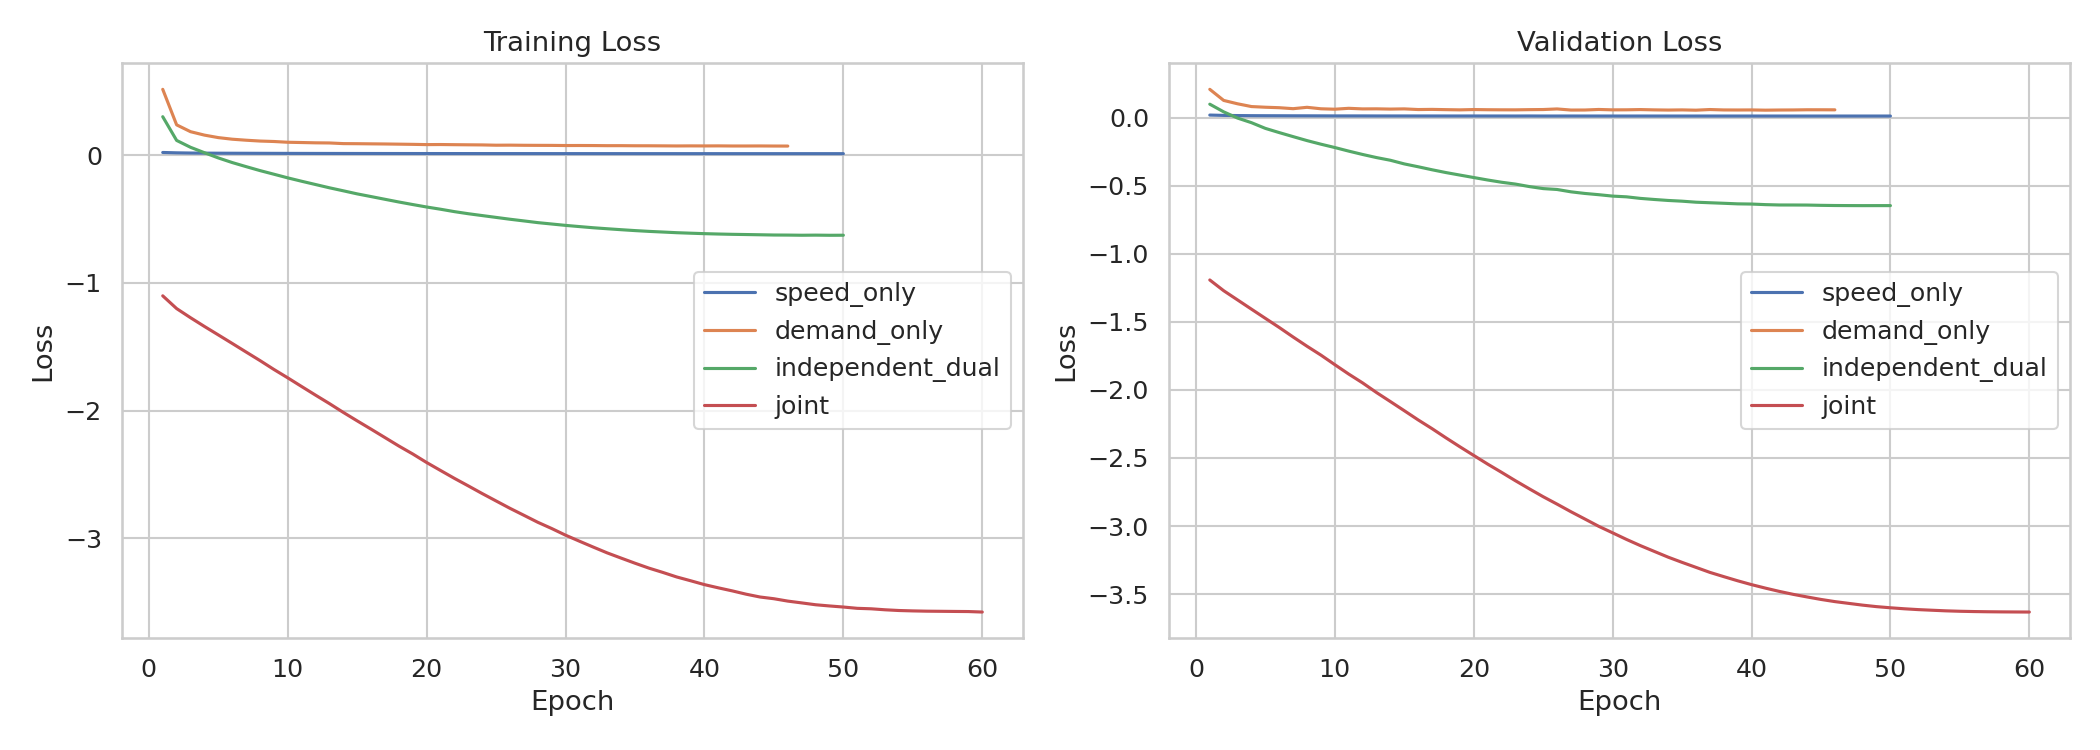

In [14]:
from IPython.display import Image, display

FIG_DIR = PROJECT_DIR / 'output' / 'figures'

print('Loss curves (all models)')
display(Image(filename=str(FIG_DIR / 'loss_curves.png')))


Overall MAE comparison


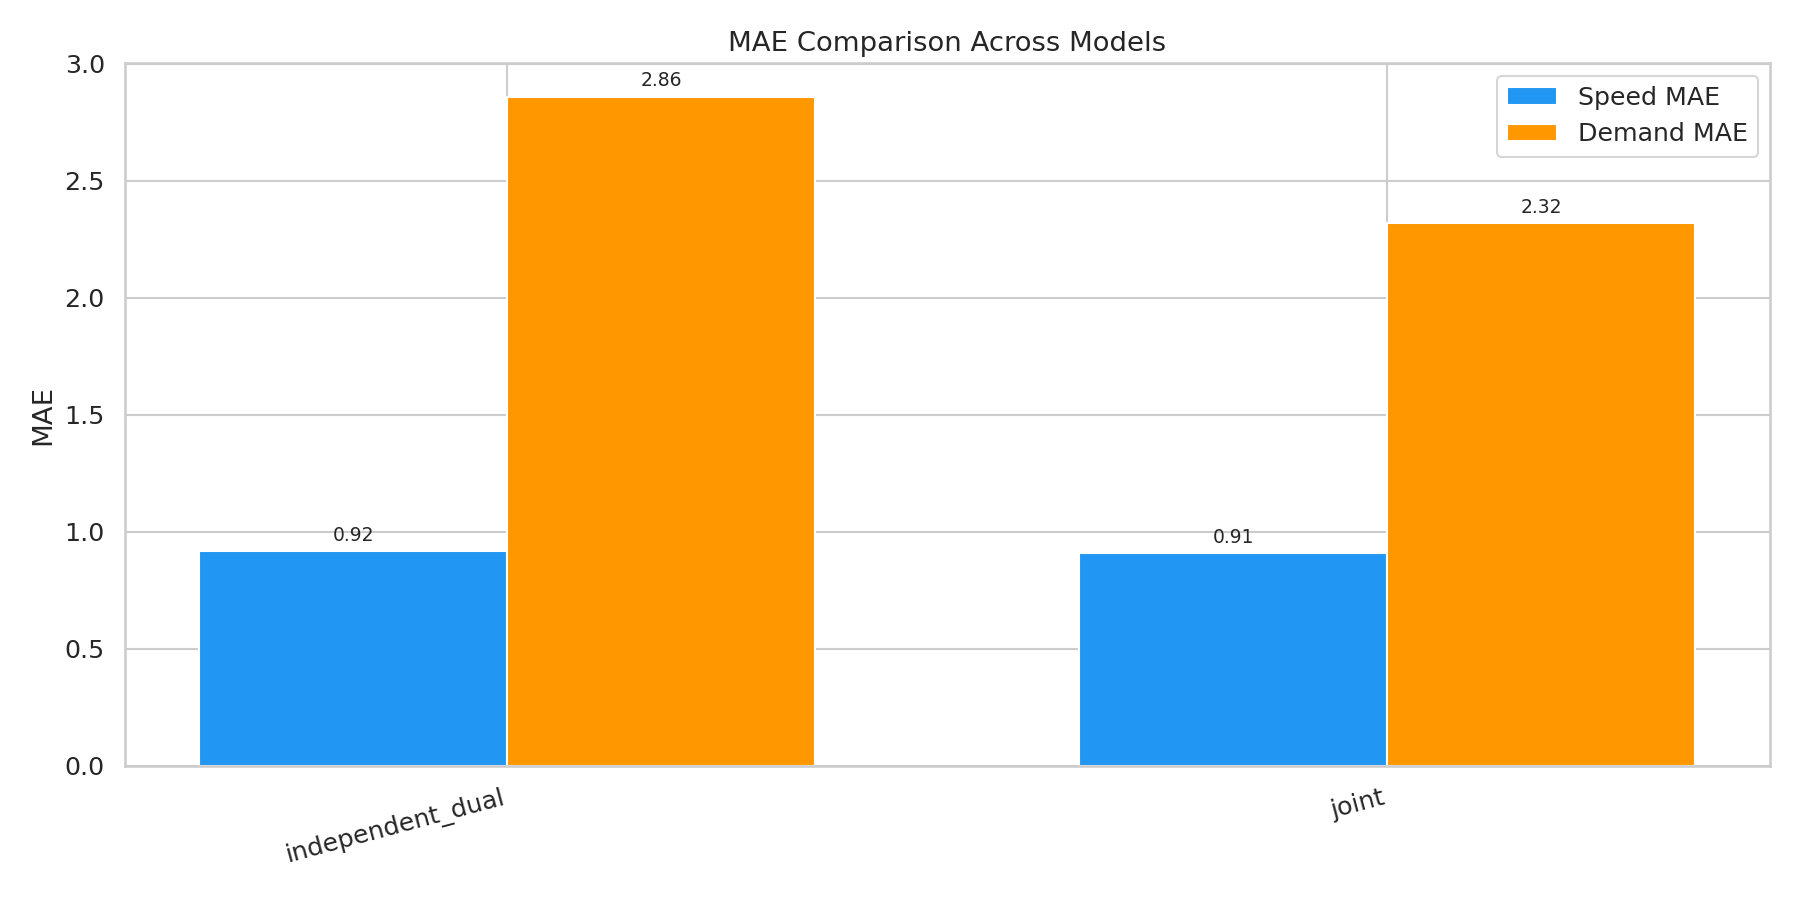

MAE by forecast horizon


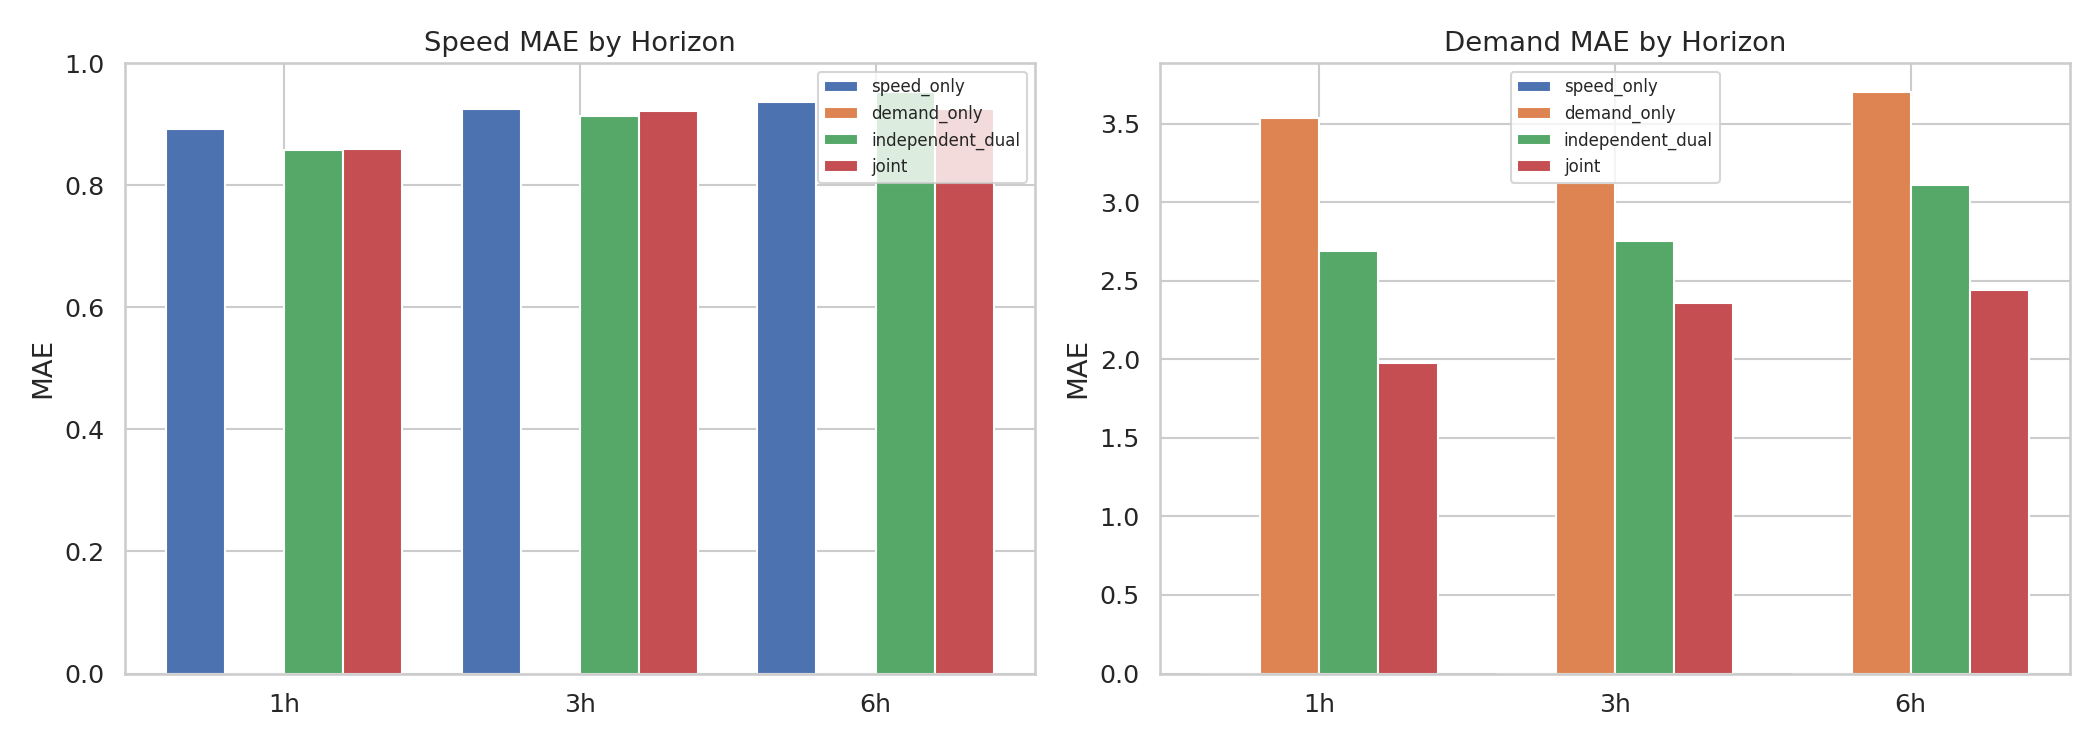

In [15]:
print('Overall MAE comparison')
display(Image(filename=str(FIG_DIR / 'mae_comparison.png')))

print('MAE by forecast horizon')
display(Image(filename=str(FIG_DIR / 'mae_by_horizon.png')))


Spatial error heatmap — Speed-Only


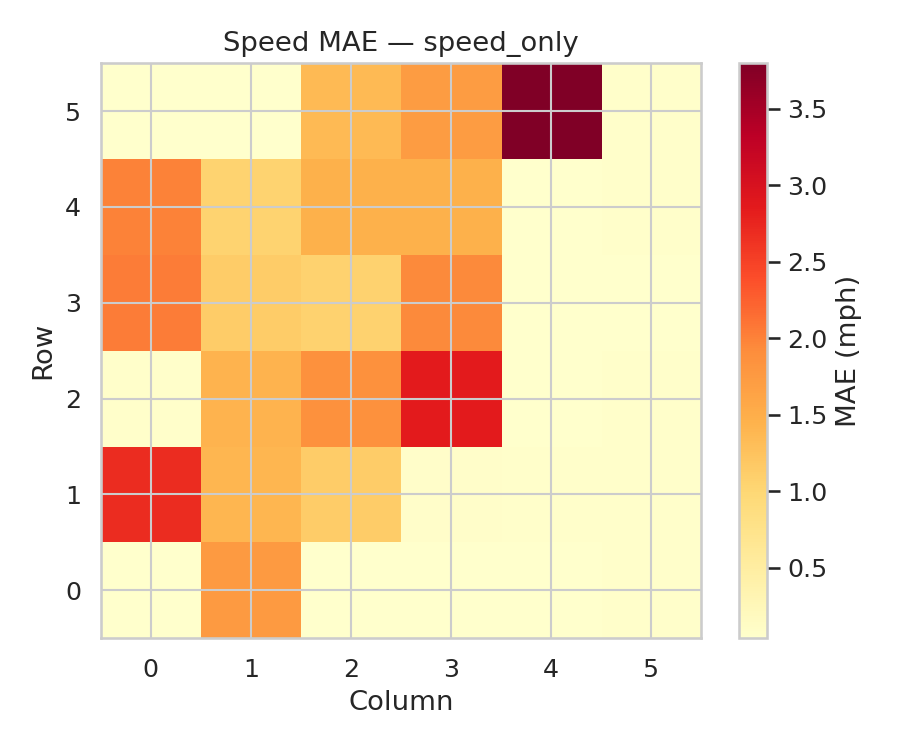

Spatial error heatmap — Demand-Only


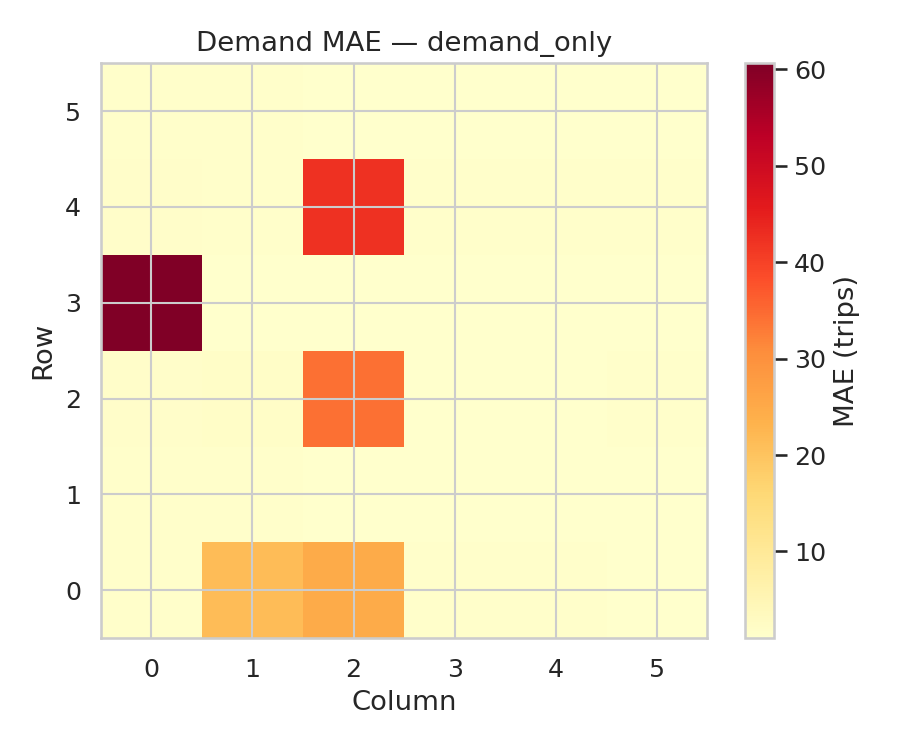

Spatial error heatmap — Independent Dual


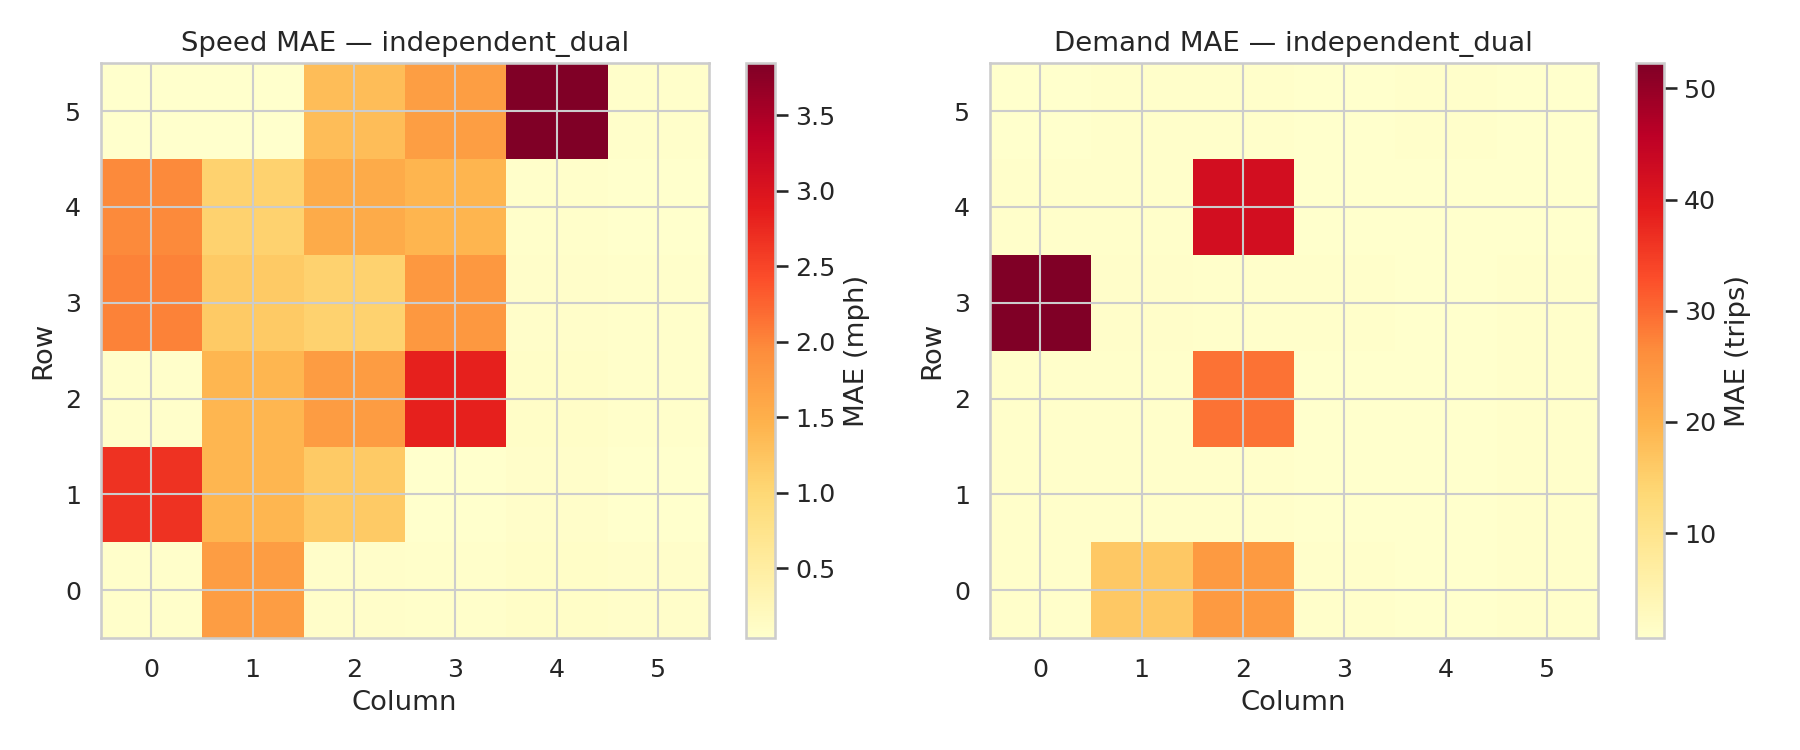

Spatial error heatmap — Joint (v8, model_v4 ensemble)


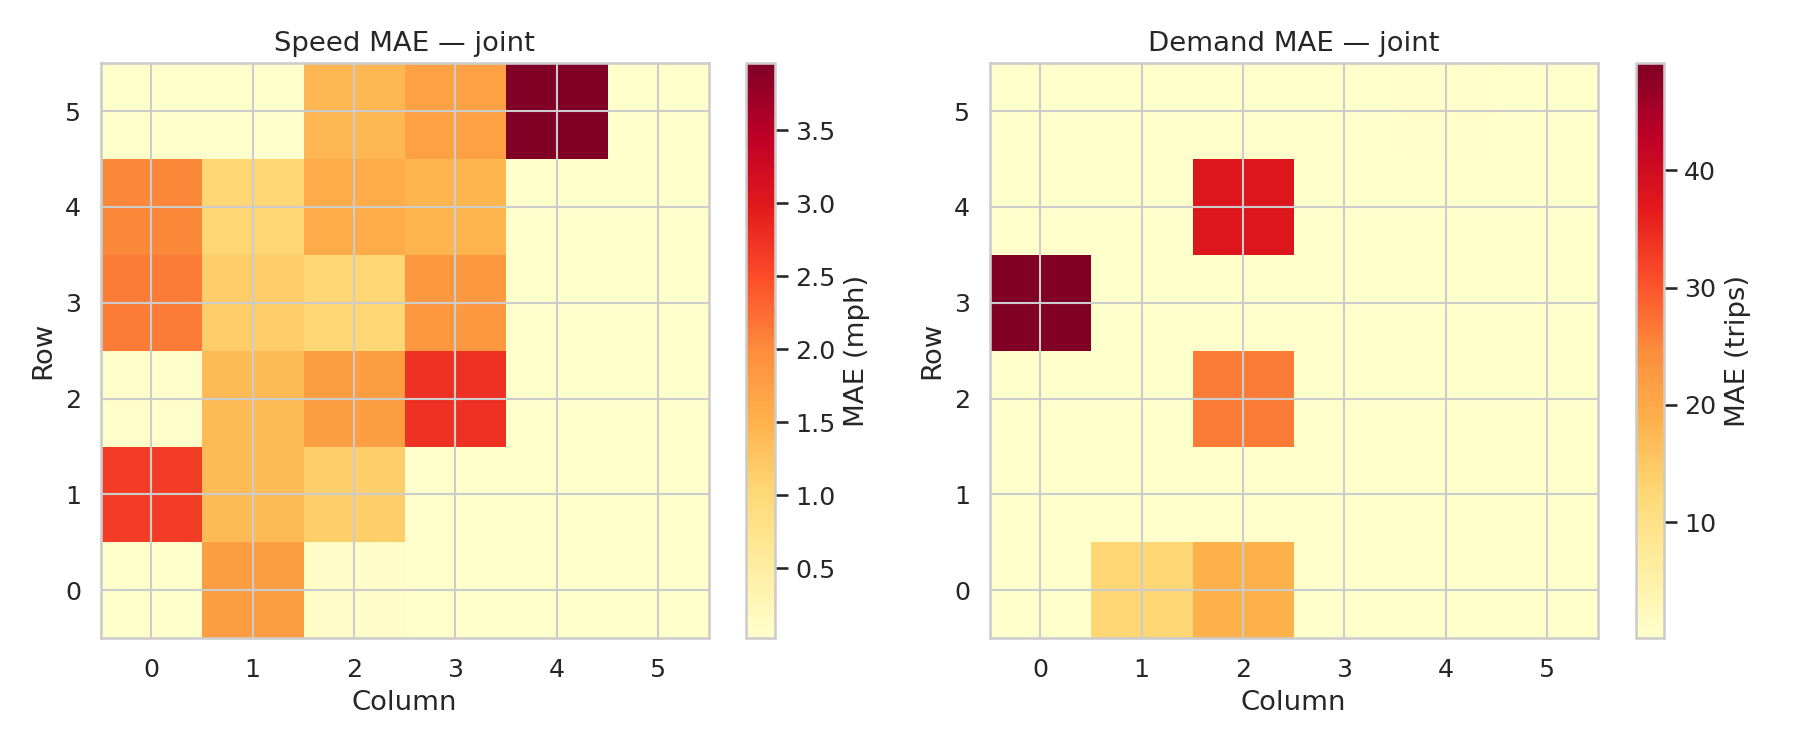

In [16]:
for model_name in MODELS:
    spatial_path = FIG_DIR / f'spatial_error_{model_name}.png'
    if spatial_path.exists():
        print(f'Spatial error heatmap — {labels[model_name]}')
        display(Image(filename=str(spatial_path)))


Time series comparison — Speed-Only


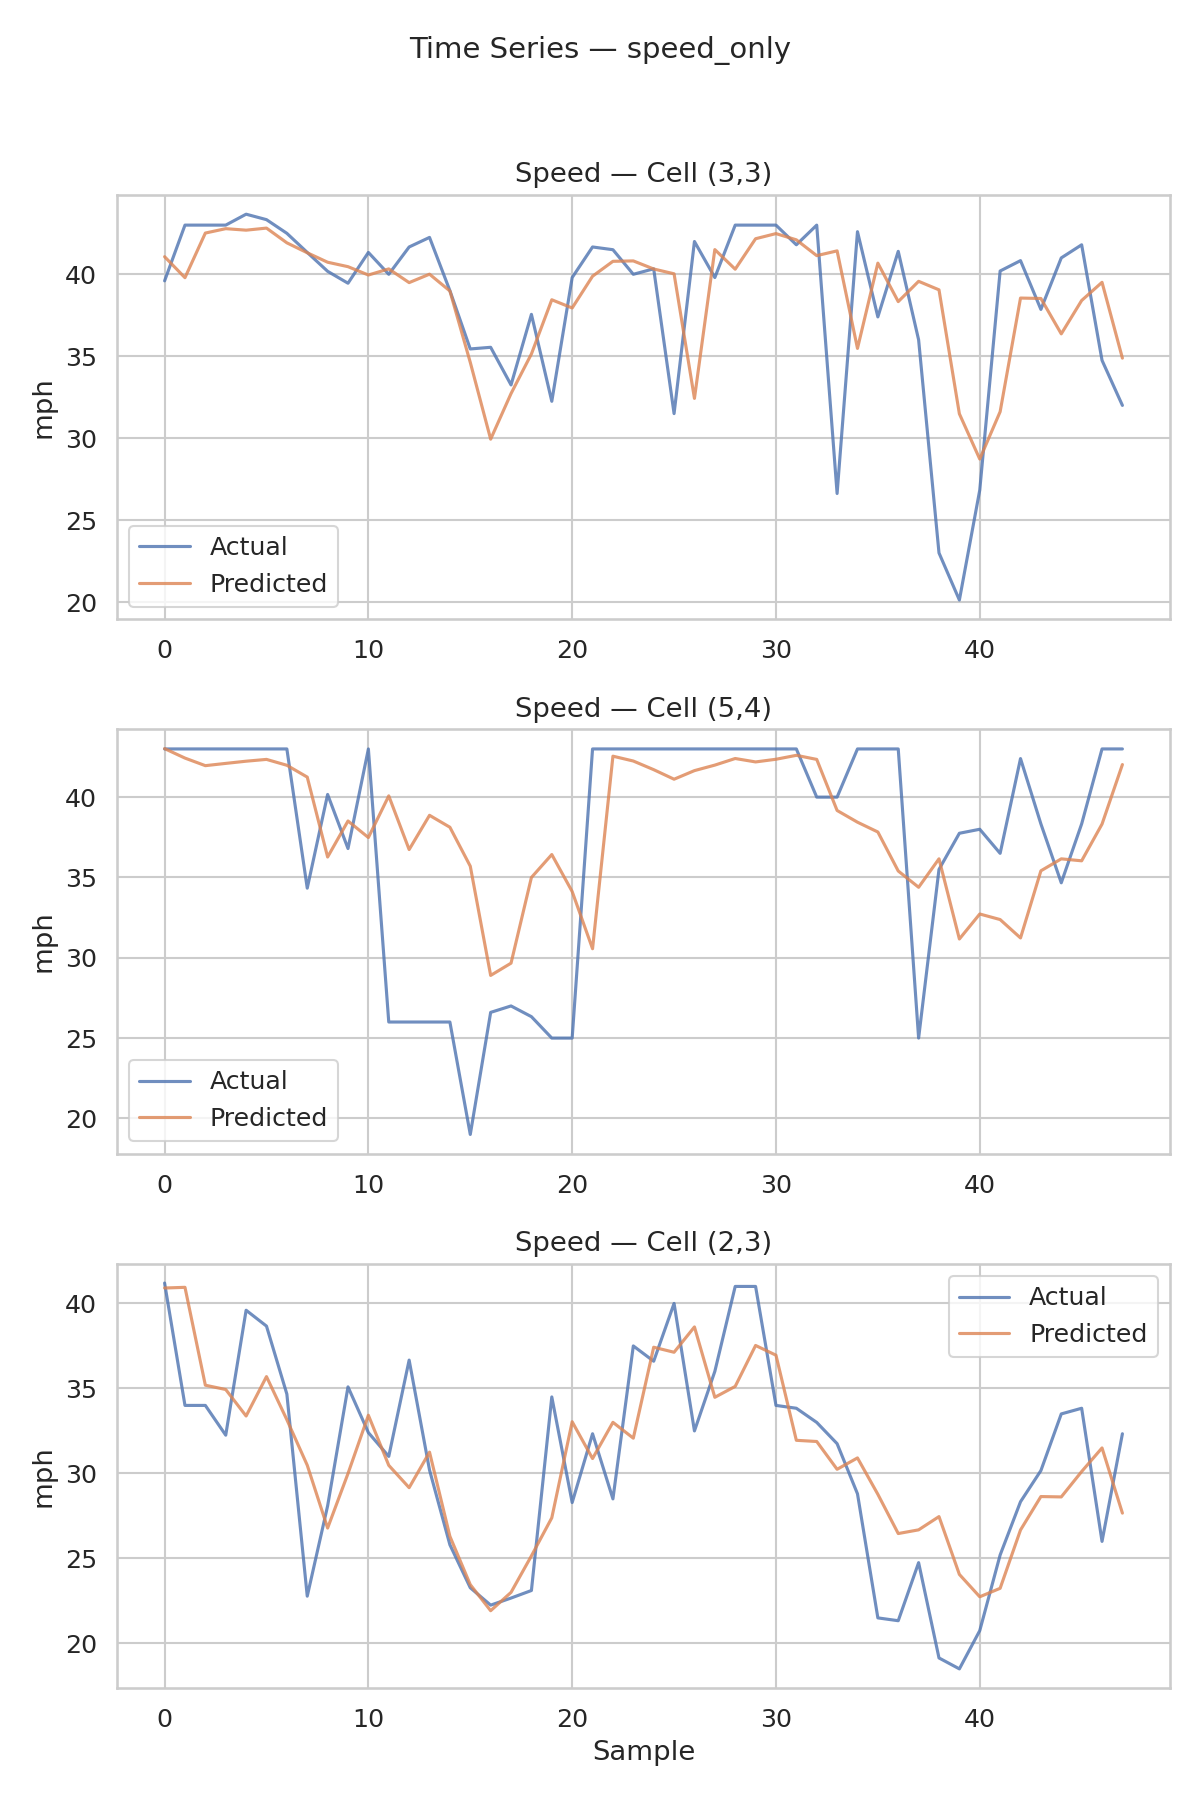

Time series comparison — Demand-Only


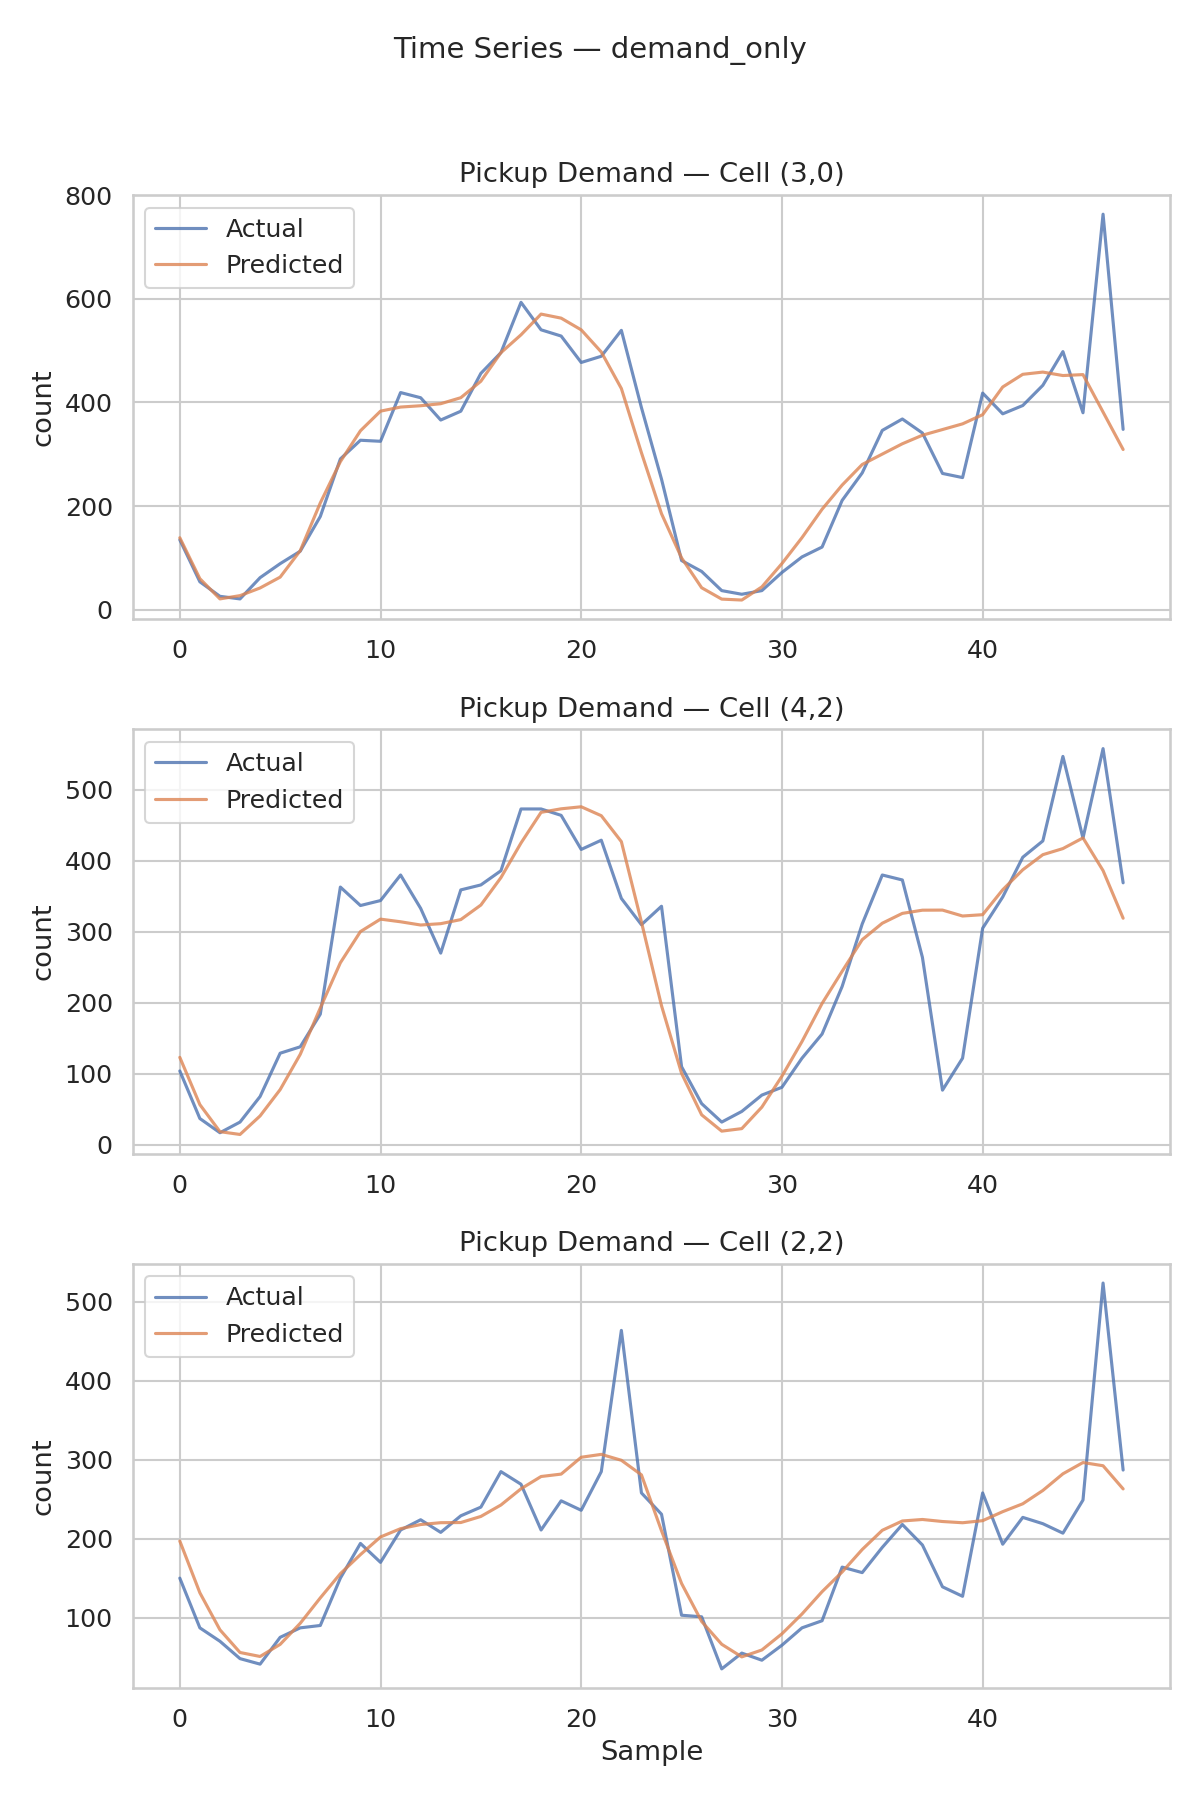

Time series comparison — Independent Dual


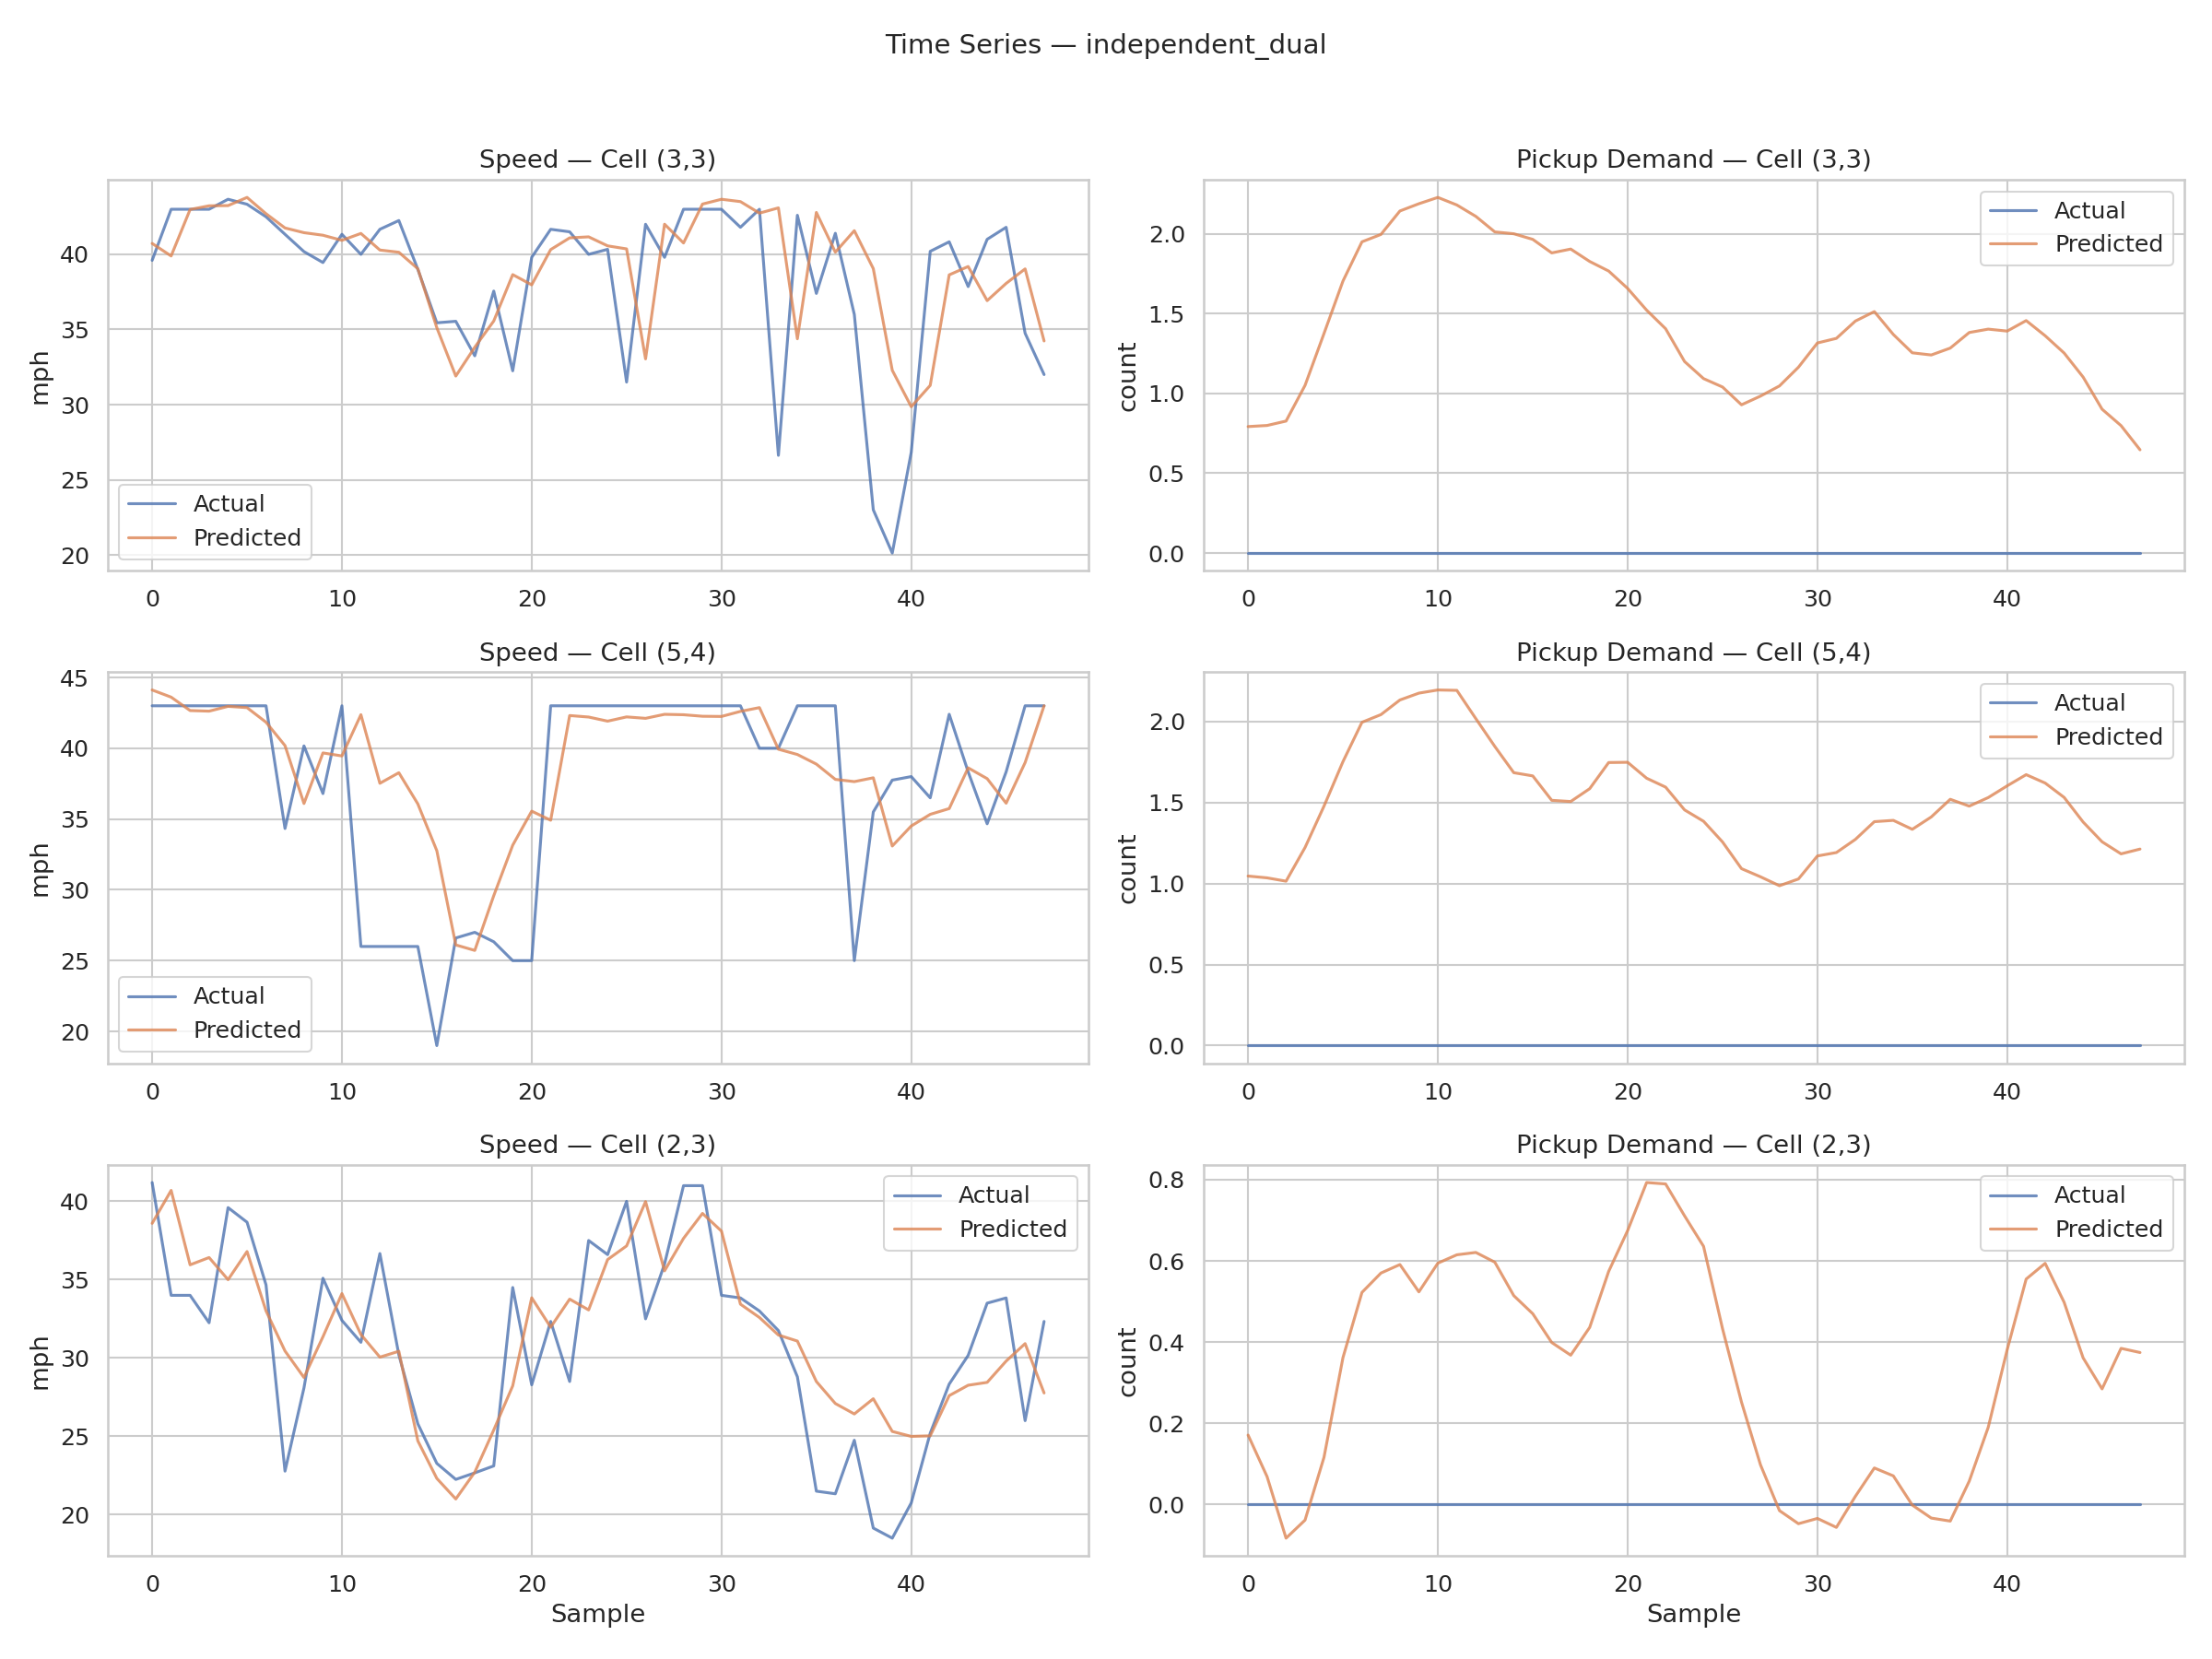

Time series comparison — Joint (v8, model_v4 ensemble)


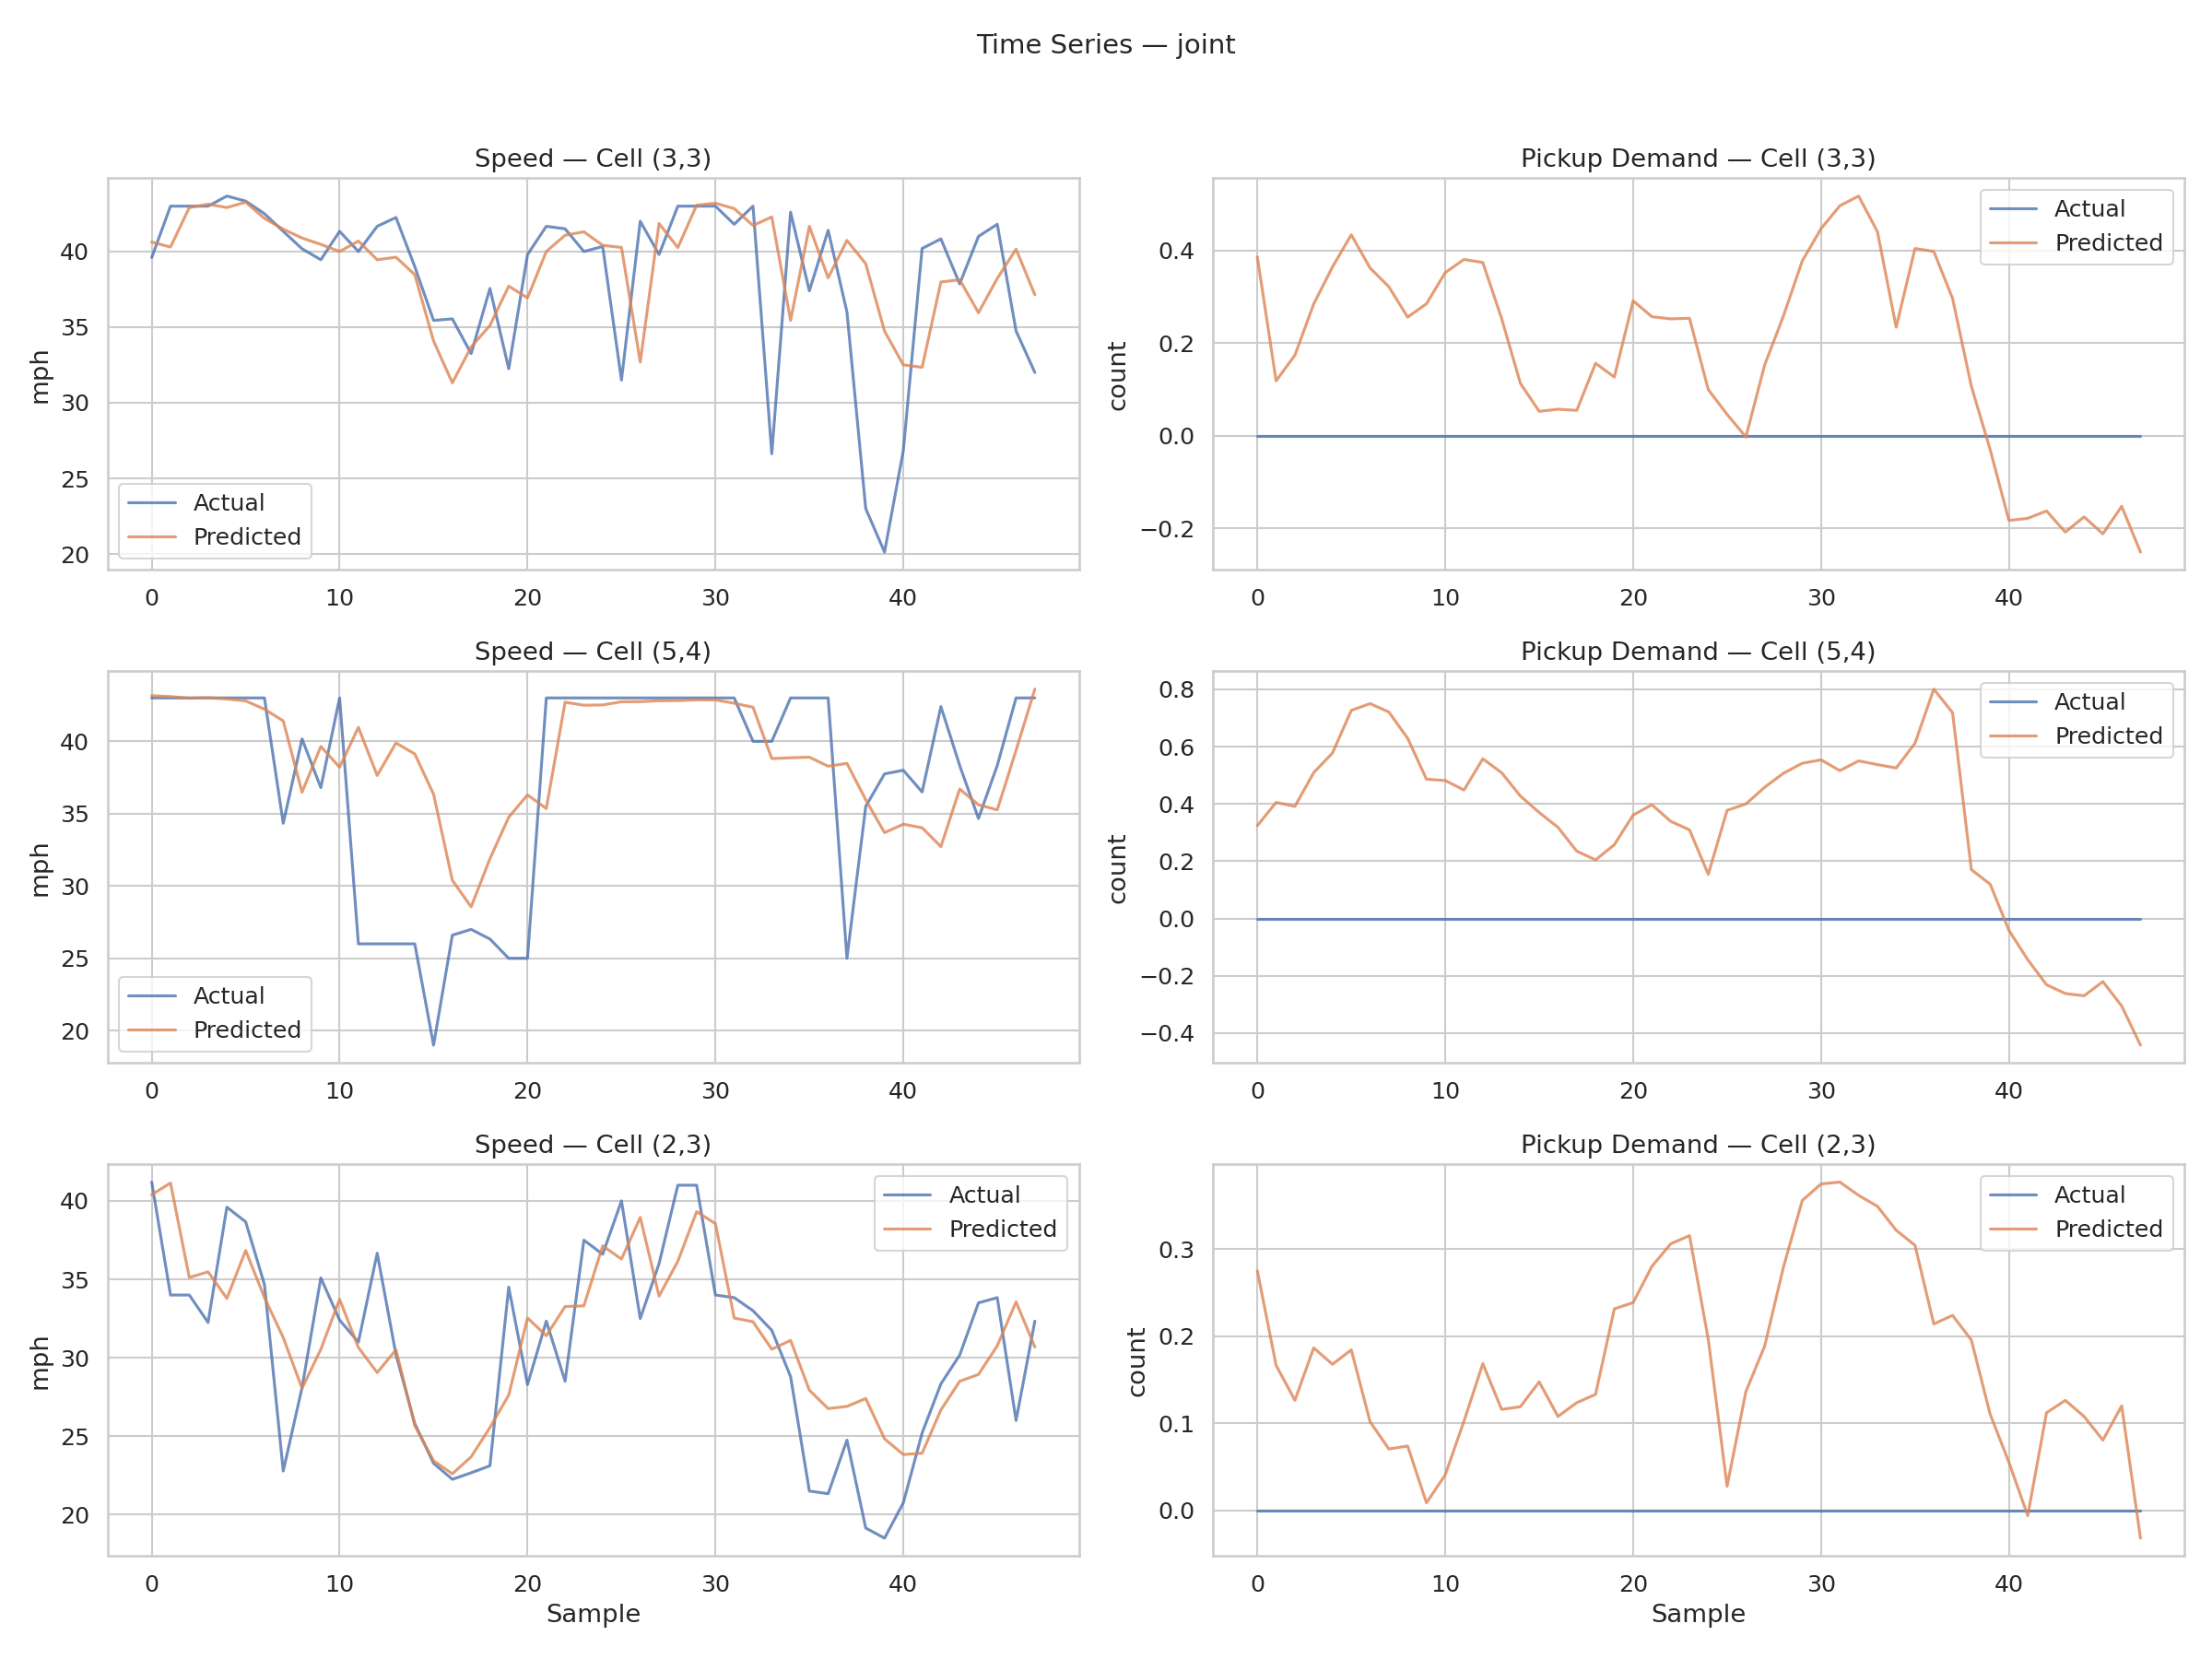

In [17]:
for model_name in MODELS:
    ts_path = FIG_DIR / f'timeseries_{model_name}.png'
    if ts_path.exists():
        print(f'Time series comparison — {labels[model_name]}')
        display(Image(filename=str(ts_path)))


## 11 · Joint ensemble details

The `joint` model in v8 is a `model_v4.JointForecaster` — an ensemble of
seed-diverse members, each combining the proven backbone with a learned
lag-mixture head. This cell reads the ensemble checkpoint directly to show
per-member validation numbers and confirm the ensemble beat every individual
member (the Bates–Granger forecast-combination signature).

In [18]:
import torch as _torch

joint_ckpt_path = CKPT_DIR / 'joint_best.pt'
if joint_ckpt_path.exists():
    ckpt = _torch.load(joint_ckpt_path, map_location='cpu', weights_only=False)
    print(f"architecture: {ckpt.get('architecture')}")
    print(f"n_members:    {ckpt.get('n_members')}")
    print(f"ensemble val — loss: {ckpt.get('val_loss'):.4f}  "
          f"speed: {ckpt.get('val_speed'):.4f}  demand: {ckpt.get('val_demand'):.4f}\n")
    for i, st in enumerate(ckpt.get('member_stats', []), start=1):
        print(f"  member {i} (seed {st['seed']}): val_loss {st['val_loss']:.4f}  "
              f"val_speed {st['val_speed']:.4f}  val_demand {st['val_demand']:.4f}")
else:
    print('No joint_best.pt found — run the training cell above first.')


architecture: model_v4
n_members:    3
ensemble val — loss: -0.7255  speed: 0.0111  demand: 0.0476

  member 1 (seed 42): val_loss -0.7205  val_speed 0.0113  val_demand 0.0504
  member 2 (seed 1337): val_loss -0.7217  val_speed 0.0114  val_demand 0.0487
  member 3 (seed 2026): val_loss -0.7224  val_speed 0.0113  val_demand 0.0487


⚠️  Unexpected keys in checkpoint (ignored): ['demand_decoder.decay_rate']


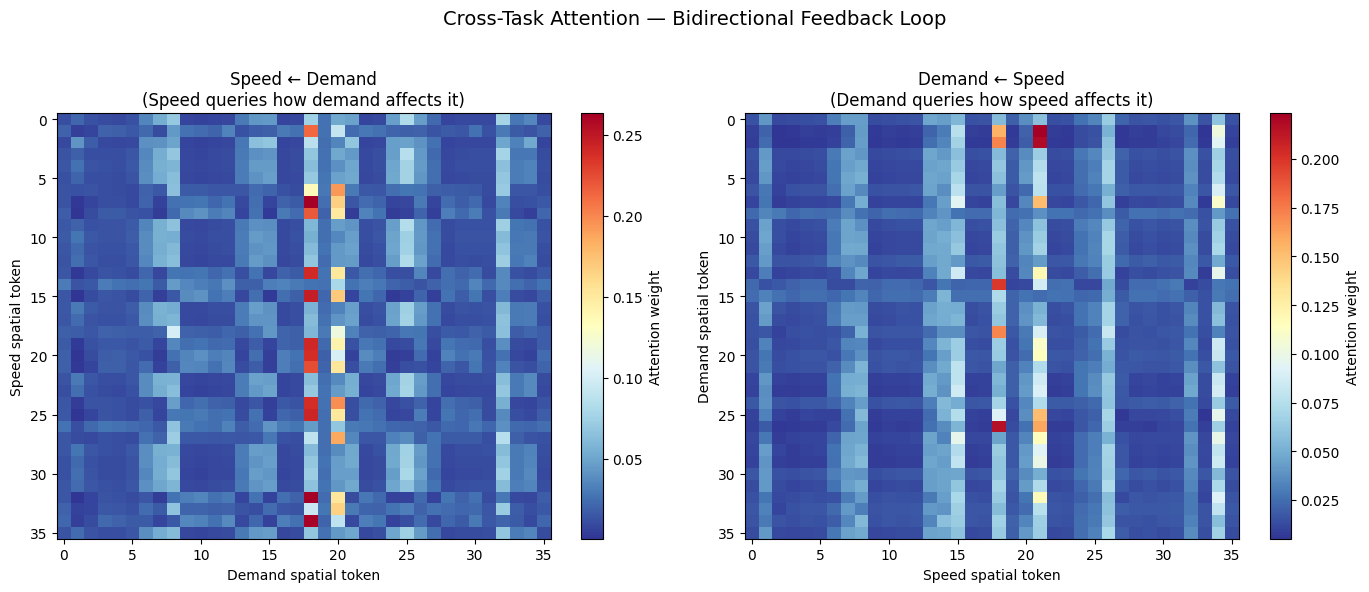

Saved: /content/drive/MyDrive/chicago-stt-cta-replicability/output/figures/cross_task_attention.png


In [20]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

import config
from model import JointForecaster
from dataset import load_preprocessed_data, TrafficDemandDataset
from torch.utils.data import DataLoader

# --- Load the original single-model checkpoint (has cross-attention) ---
# model_v4's ensemble has NO cross-task attention, so this needs the backup
# that train_v8.py automatically saved before overwriting joint_best.pt.
ckpt_path = os.path.join(config.CHECKPOINT_DIR, "joint_best_model_v2_backup.pt")
assert os.path.exists(ckpt_path), (
    f"{ckpt_path} not found. This figure requires a joint checkpoint trained "
    f"with the original model.py architecture (cross-attention), not model_v4."
)

device = config.DEVICE
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

model = JointForecaster().to(device)
missing, unexpected = model.load_state_dict(ckpt["model_state_dict"], strict=False)
if missing:
    print("⚠️  Missing keys (using model's default init for these):", missing)
if unexpected:
    print("⚠️  Unexpected keys in checkpoint (ignored):", unexpected)
model.eval()

# --- Data ---
tensor, time_index, scaler, meta = load_preprocessed_data()
config.GRID_ROWS = meta["n_rows"]
config.GRID_COLS = meta["n_cols"]

test_ds = TrafficDemandDataset(tensor, time_index, scaler, mode="test")
test_loader = DataLoader(test_ds, batch_size=4, shuffle=False, num_workers=0)

# --- Collect cross-task attention over a few batches ---
all_s2d, all_d2s = [], []
count = 0
with torch.no_grad():
    for x, _, _ in test_loader:
        x = x.to(device)
        _, _, attn_dict = model(x, need_weights=True)
        if "cross_s2d" in attn_dict:
            all_s2d.append(attn_dict["cross_s2d"].cpu().numpy())
            all_d2s.append(attn_dict["cross_d2s"].cpu().numpy())
        count += 1
        if count >= 5:
            break

assert all_s2d, "No cross_s2d attention found — checkpoint may not have cross-attention layers."

s2d = np.concatenate(all_s2d, axis=0).mean(axis=0)  # (S, S)
d2s = np.concatenate(all_d2s, axis=0).mean(axis=0)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im1 = axes[0].imshow(s2d, cmap="RdYlBu_r", aspect="auto")
axes[0].set_title("Speed ← Demand\n(Speed queries how demand affects it)")
axes[0].set_xlabel("Demand spatial token")
axes[0].set_ylabel("Speed spatial token")
plt.colorbar(im1, ax=axes[0], label="Attention weight")

im2 = axes[1].imshow(d2s, cmap="RdYlBu_r", aspect="auto")
axes[1].set_title("Demand ← Speed\n(Demand queries how speed affects it)")
axes[1].set_xlabel("Speed spatial token")
axes[1].set_ylabel("Demand spatial token")
plt.colorbar(im2, ax=axes[1], label="Attention weight")

fig.suptitle("Cross-Task Attention — Bidirectional Feedback Loop", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])

path = os.path.join(config.FIGURE_DIR, "cross_task_attention.png")
fig.savefig(path, dpi=150)
plt.show()
print(f"Saved: {path}")

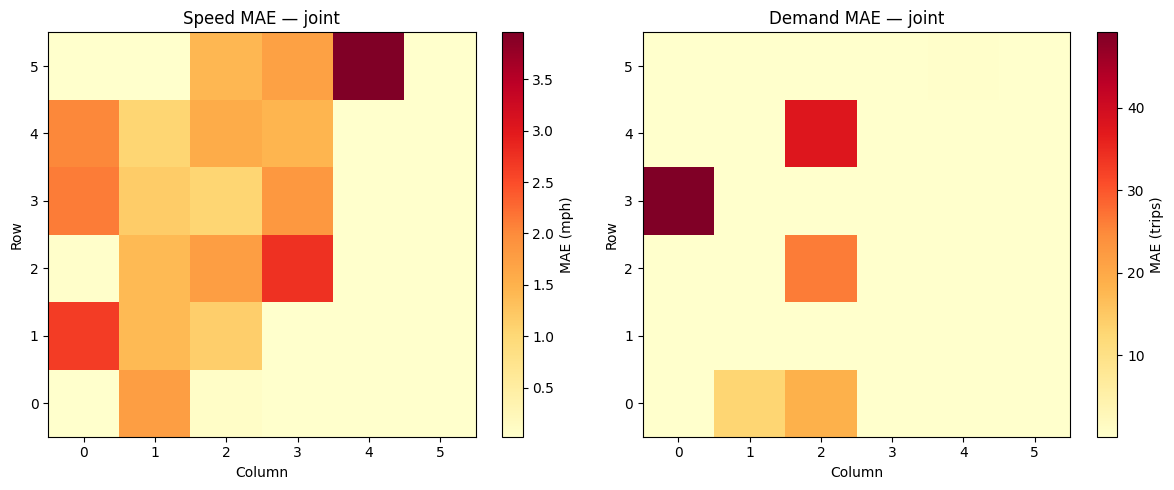

Saved: /content/drive/MyDrive/chicago-stt-cta-replicability/output/figures/spatial_error_joint.png


In [21]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

import config
import model_v4
from dataset import load_preprocessed_data
from dataset_v2 import LagAwareDataset

# --- Load the current joint ensemble (model_v4) ---
ckpt_path = os.path.join(config.CHECKPOINT_DIR, "joint_best.pt")
assert os.path.exists(ckpt_path), f"{ckpt_path} not found — train joint first."

device = config.DEVICE
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
assert ckpt.get("architecture") == "model_v4", (
    f"joint_best.pt architecture={ckpt.get('architecture')!r}, expected model_v4."
)

model = model_v4.JointForecaster(n_members=ckpt.get("n_members", 3)).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

# --- Data ---
tensor, time_index, scaler, meta = load_preprocessed_data()
config.GRID_ROWS = meta["n_rows"]
config.GRID_COLS = meta["n_cols"]

test_ds = LagAwareDataset(tensor, time_index, scaler, mode="test")
test_loader = DataLoader(test_ds, batch_size=config.BATCH_SIZE, shuffle=False)


def denormalize_speed(arr, scaler):
    mean = scaler["mean"][config.SPEED_TARGET_IDX]
    std = scaler["std"][config.SPEED_TARGET_IDX]
    return arr * std + mean


def denormalize_demand(arr, scaler):
    out = arr.copy()
    pu_mean = scaler["mean"][config.PICKUP_TARGET_IDX]
    pu_std = scaler["std"][config.PICKUP_TARGET_IDX]
    do_mean = scaler["mean"][config.DROPOFF_TARGET_IDX]
    do_std = scaler["std"][config.DROPOFF_TARGET_IDX]
    out[..., 0] = out[..., 0] * pu_std + pu_mean
    out[..., 1] = out[..., 1] * do_std + do_mean
    return out


# --- Run inference on the test set ---
all_sp, all_st, all_dp, all_dt = [], [], [], []
with torch.no_grad():
    for x, y_speed, y_demand, lag in test_loader:
        x = x.to(device)
        lag = lag.to(device)
        speed_pred, demand_pred = model(x, lag)
        all_sp.append(speed_pred.squeeze(-1).cpu().numpy())
        all_st.append(y_speed.numpy())
        all_dp.append(demand_pred.cpu().numpy())
        all_dt.append(y_demand.numpy())

sp = np.concatenate(all_sp, axis=0)
st = np.concatenate(all_st, axis=0)
dp = np.concatenate(all_dp, axis=0)
dt = np.concatenate(all_dt, axis=0)

sp = denormalize_speed(sp, scaler)
st = denormalize_speed(st, scaler)
dp = denormalize_demand(dp, scaler)
dt = denormalize_demand(dt, scaler)

# --- Plot: MAE per grid cell, speed + demand side by side ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

speed_mae = np.nanmean(np.abs(sp - st), axis=(0, 1))
im1 = axes[0].imshow(speed_mae, cmap="YlOrRd", aspect="auto", origin="lower")
axes[0].set_title("Speed MAE — joint")
axes[0].set_xlabel("Column")
axes[0].set_ylabel("Row")
plt.colorbar(im1, ax=axes[0], label="MAE (mph)")

demand_total_pred = np.nansum(dp, axis=-1)
demand_total_target = np.nansum(dt, axis=-1)
demand_mae = np.nanmean(np.abs(demand_total_pred - demand_total_target), axis=(0, 1))
im2 = axes[1].imshow(demand_mae, cmap="YlOrRd", aspect="auto", origin="lower")
axes[1].set_title("Demand MAE — joint")
axes[1].set_xlabel("Column")
axes[1].set_ylabel("Row")
plt.colorbar(im2, ax=axes[1], label="MAE (trips)")

fig.tight_layout()
path = os.path.join(config.FIGURE_DIR, "spatial_error_joint.png")
fig.savefig(path, dpi=150)
plt.show()
print(f"Saved: {path}")